In [120]:
#Import packages to setup

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Function 1

In [121]:
#Display function 1 input 2D array (10, 2)
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_1/initial_inputs.npy')

array([[0.31940389, 0.76295937],
       [0.57432921, 0.8798981 ],
       [0.73102363, 0.73299988],
       [0.84035342, 0.26473161],
       [0.65011406, 0.68152635],
       [0.41043714, 0.1475543 ],
       [0.31269116, 0.07872278],
       [0.68341817, 0.86105746],
       [0.08250725, 0.40348751],
       [0.88388983, 0.58225397]])

In [122]:
#Display function 1 output 1D array (10, )
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_1/initial_outputs.npy')

array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
        3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
       -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
        6.22985647e-048])

In [148]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# Step 1: Define the input and output data for function 1
X_train = np.array([[0.31940389, 0.76295937],
                    [0.57432921, 0.8798981 ],
                    [0.73102363, 0.73299988],
                    [0.84035342, 0.26473161],
                    [0.65011406, 0.68152635],
                    [0.41043714, 0.1475543 ],
                    [0.31269116, 0.07872278],
                    [0.68341817, 0.86105746],
                    [0.08250725, 0.40348751],
                    [0.88388983, 0.58225397]])

y_train = np.array([1.32267704e-079, 1.03307824e-046, 7.71087511e-016, 3.34177101e-124,
                    -3.60606264e-003, -2.15924904e-054, -2.08909327e-091, 2.53500115e-040,
                    3.60677119e-081, 6.22985647e-048])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-3, 1e3))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6)  #alpha is the noise parameter

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function
def expected_improvement(x, model, X_train, y_train, xi=0.05):
    """
    Expected Improvement (EI) acquisition function.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter
    """
    # Reshape x to match expected input shape
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate the improvement over the current best value
    y_best = np.min(y_train)  # Maximization problem, so use the best so far (min of y_train)
    improvement = mu - y_best - xi  # Subtract xi for exploration
    
    # If sigma is small (i.e., uncertainty is low), we return no improvement
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    
    return -ei  # We minimize, so negate the expected improvement

# Step 5: Optimize the acquisition function using scipy.optimize.minimize
def optimize_acquisition(model, X_train, y_train):
    """
    Use scipy to optimize the acquisition function and return the next query point.
    """
    # Define bounds for the search space (adjust as necessary)
    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])  # Example bounds, adjust as per the problem
    
    # Initial guess for the optimization
    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 2))
    
    # Optimize the acquisition function
    result = minimize(expected_improvement, x0, args=(model, X_train, y_train), bounds=bounds, method="L-BFGS-B")
    
    # Return the next point to sample
    return result.x

# Step 6: Find the next query point
next_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Output the next query point in the required format (x, y) as 'x-y'
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Next query point: {next_point_str}")

Next query point: 0.609953-0.506520


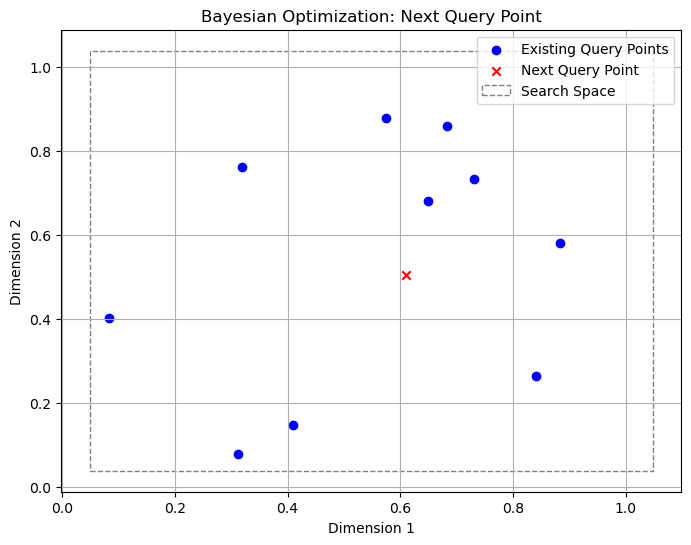

In [149]:
# Step 8: Plot the results
plt.figure(figsize=(8, 6))

# Plot the existing data points (X_train)
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label='Existing Query Points')

# Plot the next query point
plt.scatter(next_point[0], next_point[1], color='red', marker='x', label='Next Query Point')

# Plot the search space (defined by the fixed length around the center)
center = np.mean(X_train, axis=0)  # Center of X_train
plt.gca().add_patch(plt.Rectangle((center[0] - 0.5, center[1] - 0.5), 1.0, 1.0, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--', label='Search Space'))

# Labels and legend
plt.title("Bayesian Optimization: Next Query Point")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

## Function 2 

#### Steps:

Gaussian Process Model: We'll use a Gaussian Process (GP) as a surrogate model to approximate the function, which is well-suited for noisy functions.

Acquisition Function: The Expected Improvement (EI) will be used as the acquisition function, but we will adjust it for more exploration (by tweaking the xi parameter).

Optimization Process: The next query point will be selected by maximizing the acquisition function, which suggests where to query the function next based on the current knowledge.

In [155]:
# Function 2 2D array (10, 2) input values
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_2/initial_inputs.npy')

array([[0.66579958, 0.12396913],
       [0.87779099, 0.7786275 ],
       [0.14269907, 0.34900513],
       [0.84527543, 0.71112027],
       [0.45464714, 0.29045518],
       [0.57771284, 0.77197318],
       [0.43816606, 0.68501826],
       [0.34174959, 0.02869772],
       [0.33864816, 0.21386725],
       [0.70263656, 0.9265642 ]])

In [156]:
# Function 2 1D array (10, ) output values
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_2/initial_outputs.npy')

array([ 0.53899612,  0.42058624, -0.06562362,  0.29399291,  0.21496451,
        0.02310555,  0.24461934,  0.03874902, -0.01385762,  0.61120522])

Next query point: 0.734909-0.701711


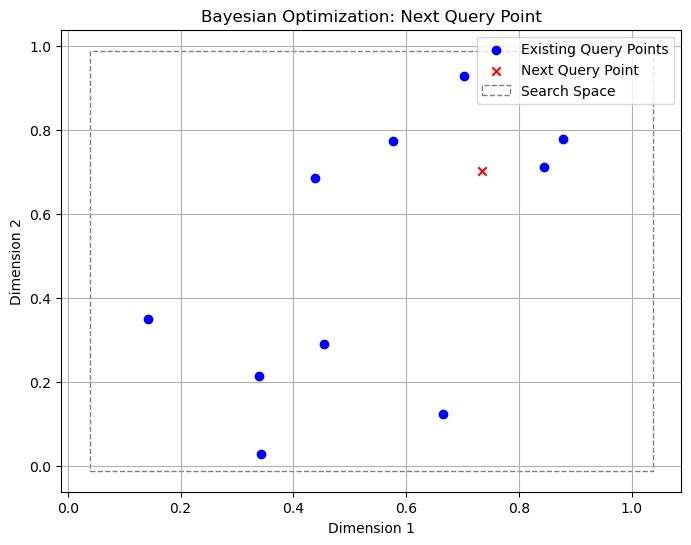

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# Step 1: Define the input and output data for function 2
X_train = np.array([[0.66579958, 0.12396913],
                    [0.87779099, 0.7786275 ],
                    [0.14269907, 0.34900513],
                    [0.84527543, 0.71112027],
                    [0.45464714, 0.29045518],
                    [0.57771284, 0.77197318],
                    [0.43816606, 0.68501826],
                    [0.34174959, 0.02869772],
                    [0.33864816, 0.21386725],
                    [0.70263656, 0.9265642 ]])

y_train = np.array([1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
                    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
                    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
                    6.22985647e-048])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)  #increase alpha to handle excess noise

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    """
    Expected Improvement (EI) acquisition function with exploration.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter (larger xi = more exploration)
    """
    # Reshape x to match expected input shape
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate the improvement over the current best value
    y_best = np.max(y_train)  # Maximization problem, so use the best so far (max of y_train)
    improvement = mu - y_best - xi  # Subtract xi for exploration
    
    # If sigma is small (i.e., uncertainty is low), we return no improvement
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    
    return -ei  # We minimize, so negate the expected improvement

# Step 5: Optimize the acquisition function using scipy.optimize.minimize
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    """
    Use scipy to optimize the acquisition function and return the next query point.
    In this version, the bounds are set based on a fixed length (radius) from the center of the observed points.
    """
    # Step 5a: Define the center of the search space (mean of X_train)
    center = np.mean(X_train, axis=0)  # Mean of the points in X_train (central point)
    
    # Step 5b: Set bounds based on the length (radius) around the center
    bounds = np.array([[center[0] - length, center[0] + length],  # Bounds for the first dimension
                       [center[1] - length, center[1] + length]])  # Bounds for the second dimension
    
    # Step 5c: Initial guess for optimization (random point within bounds)
    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 2))
    
    # Step 5d: Optimize the acquisition function to find the next query point (mininising negates to maximise)
    result = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi), bounds=bounds, method="L-BFGS-B")
    
    # Return the next query point
    return result.x

# Step 6: Find the next query point with higher exploration (xi=0.1)
next_point = optimize_acquisition(gp, X_train, y_train, length=0.5, xi=0.1)

# Step 7: Output the next query point in the required format (x, y) as 'x-y'
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Next query point: {next_point_str}")

# Step 8: Plot the results
plt.figure(figsize=(8, 6))

# Plot the existing data points (X_train)
plt.scatter(X_train[:, 0], X_train[:, 1], color='blue', label='Existing Query Points')

# Plot the next query point
plt.scatter(next_point[0], next_point[1], color='red', marker='x', label='Next Query Point')

# Plot the search space (defined by the fixed length around the center)
center = np.mean(X_train, axis=0)  # Center of X_train
plt.gca().add_patch(plt.Rectangle((center[0] - 0.5, center[1] - 0.5), 1.0, 1.0, linewidth=1, edgecolor='gray', facecolor='none', linestyle='--', label='Search Space'))

# Labels and legend
plt.title("Bayesian Optimization: Next Query Point")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

## Function 3

Given the task at hand, Function 3 is a 3D optimisation problem for drug discovery, where you aim to minimise side effects (which is framed as a maximisation problem by optimizing a transformed output, e.g., the negative of side effects). The goal is to prioritize exploration over exploitation in Week 1 of the optimisation process to ensure we don't get stuck in local optima, especially when the function is noisy.

Key Insights:

Input Space: The input to Function 3 is a 3D array representing the three compounds used in the drug discovery experiments. Each row in the array corresponds to a different experiment, with three values indicating the amounts of the three compounds.

Output Space: The output of Function 3 is a 1D array of values that correspond to the number of adverse reactions from each experiment. This value is transformed (e.g., by taking its negative) to make it a maximisation problem.

Goal: The aim is to minimise the adverse effects (maximise the transformed value), which is typically done by using Bayesian optimisation and prioritising exploration to discover new areas of the search space that might lead to better combinations of the compounds.

Approach:

1. Gaussian Process (GP): We'll use a Gaussian Process as a surrogate model. GP models are good for optimisation problems where the function is black-box and expensive to evaluate. It also allows us to quantify uncertainty in predictions.

2. Acquisition Function: We will use the Expected Improvement (EI) acquisition function, which allows us to balance exploration (trying out uncertain areas) and exploitation (focusing on areas that have shown good results). Since you want to prioritise exploration in Week 1, we can tune the acquisition function to encourage more exploration by setting the exploration-exploitation parameter (xi) to a higher value (e.g., xi=0.1).

3. Optimisation: The optimisation process will be conducted in the 3D space to identify the next best combination of compounds (i.e. next query point).

In [154]:
# Function 3 input values 3D array (15, 3)
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_3/initial_inputs.npy')

array([[0.17152521, 0.34391687, 0.2487372 ],
       [0.24211446, 0.64407427, 0.27243281],
       [0.53490572, 0.39850092, 0.17338873],
       [0.49258141, 0.61159319, 0.34017639],
       [0.13462167, 0.21991724, 0.45820622],
       [0.34552327, 0.94135983, 0.26936348],
       [0.15183663, 0.43999062, 0.99088187],
       [0.64550284, 0.39714294, 0.91977134],
       [0.74691195, 0.28419631, 0.22629985],
       [0.17047699, 0.6970324 , 0.14916943],
       [0.22054934, 0.29782524, 0.34355534],
       [0.66601366, 0.67198515, 0.2462953 ],
       [0.04680895, 0.23136024, 0.77061759],
       [0.60009728, 0.72513573, 0.06608864],
       [0.96599485, 0.86111969, 0.56682913]])

In [158]:
# Function 3 output values 1D array (15, )
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_3/initial_outputs.npy')

array([-0.1121222 , -0.08796286, -0.11141465, -0.03483531, -0.04800758,
       -0.11062091, -0.39892551, -0.11386851, -0.13146061, -0.09418956,
       -0.04694741, -0.10596504, -0.11804826, -0.03637783, -0.05675837])

Next query point: 0.836816-0.551524-0.084734


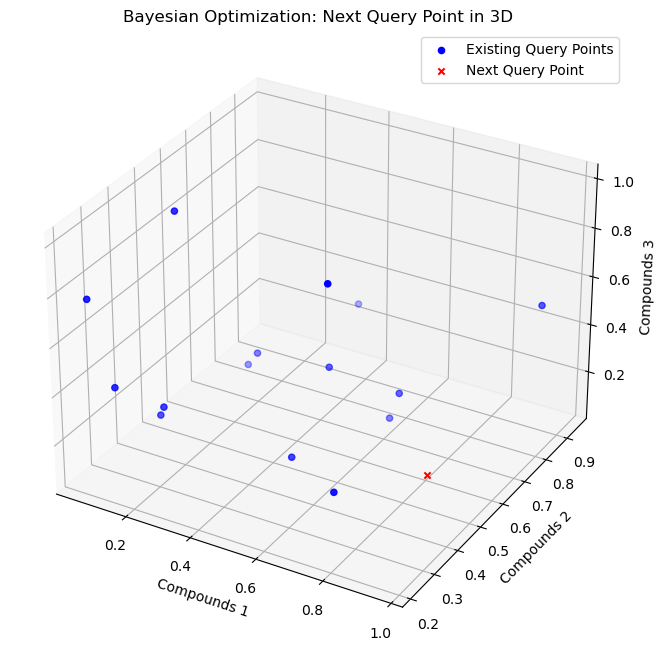

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize

# Step 1: Define the input and output data for function 3 (drug discovery)
X_train = np.array([[0.17152521, 0.34391687, 0.2487372 ],
                    [0.24211446, 0.64407427, 0.27243281],
                    [0.53490572, 0.39850092, 0.17338873],
                    [0.49258141, 0.61159319, 0.34017639],
                    [0.13462167, 0.21991724, 0.45820622],
                    [0.34552327, 0.94135983, 0.26936348],
                    [0.15183663, 0.43999062, 0.99088187],
                    [0.64550284, 0.39714294, 0.91977134],
                    [0.74691195, 0.28419631, 0.22629985],
                    [0.17047699, 0.6970324 , 0.14916943],
                    [0.22054934, 0.29782524, 0.34355534],
                    [0.66601366, 0.67198515, 0.2462953 ],
                    [0.04680895, 0.23136024, 0.77061759],
                    [0.60009728, 0.72513573, 0.06608864],
                    [0.96599485, 0.86111969, 0.56682913]])

y_train = np.array([-0.1121222 , -0.08796286, -0.11141465, -0.03483531, -0.04800758,
                    -0.11062091, -0.39892551, -0.11386851, -0.13146061, -0.09418956,
                    -0.04694741, -0.10596504, -0.11804826, -0.03637783, -0.05675837])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    """
    Expected Improvement (EI) acquisition function with exploration.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter (larger xi = more exploration)
    """
    # Reshape x to match expected input shape
    x = np.array(x).reshape(1, -1)
    
    # Predict the mean and standard deviation at the new point
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate the improvement over the current best value
    y_best = np.max(y_train)  # Maximization problem, so use the best so far (max of y_train)
    improvement = mu - y_best - xi  # Subtract xi for exploration
    
    # If sigma is small (i.e., uncertainty is low), we return no improvement
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    
    return -ei  # We minimize, so negate the expected improvement

# Step 5: Optimize the acquisition function using scipy.optimize.minimize
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    """
    Use scipy to optimize the acquisition function and return the next query point.
    In this version, the bounds are set based on a fixed length (radius) from the center of the observed points.
    """
    # Step 5a: Define the center of the search space (mean of X_train)
    center = np.mean(X_train, axis=0)  # Mean of the points in X_train (central point)
    
    # Step 5b: Set bounds based on the length (radius) around the center
    bounds = np.array([[center[0] - length, center[0] + length],  # Bounds for the first dimension
                       [center[1] - length, center[1] + length],  # Bounds for the second dimension
                       [center[2] - length, center[2] + length]])  # Bounds for the third dimension
    
    # Step 5c: Initial guess for optimization (random point within bounds)
    x0 = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(1, 3))
    
    # Step 5d: Optimize the acquisition function to find the next query point
    result = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi), bounds=bounds, method="L-BFGS-B")
    
    # Return the next query point
    return result.x

# Step 6: Find the next query point with higher exploration (xi=0.1)
next_point = optimize_acquisition(gp, X_train, y_train, length=0.5, xi=0.1)

# Step 7: Output the next query point in the required format (x, y, z) as 'x-y-z'
next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}"
print(f"Next query point: {next_point_str}")

# Step 8: Plot the results (in 3D)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the existing data points (X_train)
ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c='blue', label='Existing Query Points')

# Plot the next query point
ax.scatter(next_point[0], next_point[1], next_point[2], c='red', marker='x', label='Next Query Point')

# Labels and legend
ax.set_title("Bayesian Optimization: Next Query Point in 3D")
ax.set_xlabel("Compounds 1")
ax.set_ylabel("Compounds 2")
ax.set_zlabel("Compounds 3")
ax.legend()

# Show the plot
plt.show()

## Function 4

### Explanation of the Result for Function 4:

The plot and the printed output provide insights into the next query point selected by Bayesian optimization for Function 4, where we are trying to optimally place products across warehouses with four hyperparameters.

#### Plot Overview:

Blue Dots (Existing Points): These represent the existing query points in the 4D input space, visualized in 2D after applying Principal Component Analysis (PCA) to reduce the dimensionality from 4D to 2D. The existing points are the locations where the model (Function 4) has already been evaluated.

Red Dot (Next Query Point): The red dot represents the next query point selected by the optimization process. This is the point that the Bayesian Optimization algorithm suggests for the next evaluation of Function 4. The goal is to explore the parameter space and maximize the model output by selecting points where the model has high uncertainty (exploration).

#### Key Observations:

Next Query Point:
The red dot indicates the next point to be evaluated by Function 4. This point is the one that the algorithm believes has the highest potential for improving the performance based on the current model (the Gaussian Process model) and its acquisition function (Expected Improvement with exploration).

The printed 4D coordinates of the next query point are:

[0.91914352, 0.53319598, 0.16984802, 0.07005427]

This means that the next query point corresponds to these four values of the hyperparameters for the model.

#### Exploration:

The next query point is positioned in a region that has not been explored much by the previous query points, suggesting that the model is focusing more on exploration.

The Expected Improvement (EI) acquisition function with a higher xi parameter (set to 0.1) encourages the model to explore areas where there is higher uncertainty, rather than exploiting areas that have already shown good results.

#### PCA Visualization:

The plot shows the 2D projection of the original 4D input space. Since visualizing 4D directly is not feasible, PCA reduces the 4D data to 2D for easier visualization.

The PCA plot does not directly correspond to the real values of the input hyperparameters but instead represents a projection of the data into a 2D plane. The goal is to give a sense of the relationship between the query points in the original 4D space.

Position of the Next Query Point:

The next query point (red dot) is located in an area of the PCA-reduced space where few points have been sampled so far (around the middle-left region of the plot). This confirms that the optimizer is focusing on exploring this under-sampled region, where the model has high uncertainty, rather than exploiting the regions where the function has already been evaluated.

#### Why is this an Exploration?

The key idea behind prioritizing exploration over exploitation is to explore regions that have not been sampled much, particularly in the presence of local optima.

The red dot's location suggests that the optimizer is trying to find areas of the parameter space that may lead to a better solution or provide more information to refine the model.

Next Steps:

The next query point will be evaluated by Function 4, and this process will help to guide the optimization towards better solutions by balancing exploration and exploitation in subsequent iterations.

After evaluating this new point, the optimization process will update the model, and the next query point will be selected similarly based on the updated information.

This process will continue iteratively until the optimization reaches a satisfactory solution or the maximum number of iterations is reached.

#### Summary:

Function 4 aims to optimize a system with 4 hyperparameters. The algorithm is prioritizing exploration over exploitation in the first iteration to gather more diverse data and avoid getting stuck in local optima.

The next query point is chosen in an area of the input space that hasn't been well-explored yet, as evidenced by the PCA plot and the selection of a point in a less-sampled region.

In [161]:
# Function 4 input values 4D array (30, 4)
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_4/initial_inputs.npy')

array([[0.89698105, 0.72562797, 0.17540431, 0.70169437],
       [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
       [0.25094624, 0.03369313, 0.14538002, 0.49493242],
       [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
       [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
       [0.80130271, 0.50023109, 0.70664456, 0.19510284],
       [0.24770826, 0.06044543, 0.04218635, 0.44132425],
       [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
       [0.40066503, 0.07257425, 0.88676825, 0.24384229],
       [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
       [0.95713529, 0.59764438, 0.76611385, 0.77620991],
       [0.73281243, 0.14524998, 0.47681272, 0.13336573],
       [0.65511548, 0.07239183, 0.68715175, 0.08151656],
       [0.21973443, 0.83203134, 0.48286416, 0.08256923],
       [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
       [0.16713049, 0.87655456, 0.21723954, 0.95980098],
       [0.21691119, 0.16608583, 0.24137226, 0.77006248],
       [0.38748784, 0.80453226,

In [163]:
# Function 4 output values 1D array (30, )
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_4/initial_outputs.npy')

array([-22.10828779, -14.60139663, -11.69993246, -16.05376511,
       -10.06963343, -15.48708254, -12.68168498, -16.02639977,
       -17.04923465, -12.74176599, -27.31639636, -13.52764887,
       -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
       -12.75832422, -19.44155762, -28.90327367, -13.70274694,
       -29.4270914 , -11.56574199, -26.85778644,  -7.96677535,
        -6.70208925, -32.62566022, -19.98949793,  -4.02554228,
       -13.12278233, -23.1394284 ])

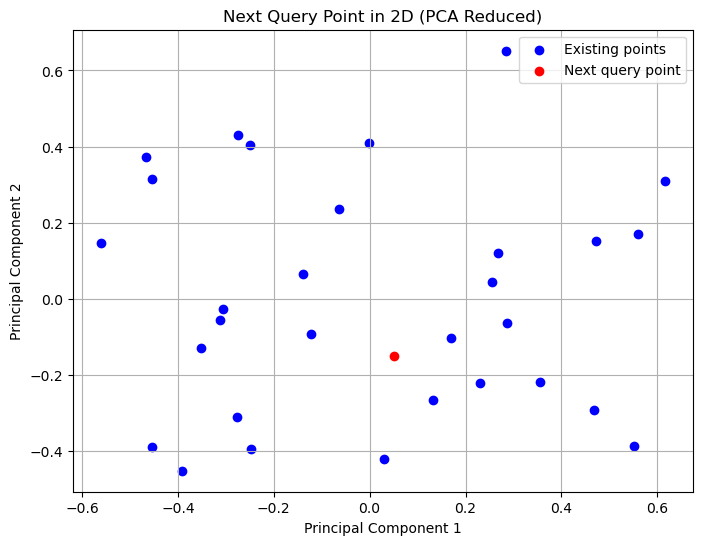

Next query point in 4D: [0.91914352 0.53319598 0.16984802 0.07005427]


In [165]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 4 (warehouse optimization)
X_train = np.array([[0.89698105, 0.72562797, 0.17540431, 0.70169437],
                    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
                    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
                    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
                    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
                    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
                    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
                    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
                    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
                    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
                    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
                    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
                    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
                    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
                    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
                    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
                    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
                    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
                    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
                    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
                    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
                    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
                    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
                    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
                    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
                    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
                    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
                    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
                    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
                    [0.8548108 , 0.49396462, 0.73530997, 0.80809201]])

y_train = np.array([-22.10828779, -14.60139663, -11.69993246, -16.05376511,
                    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
                    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
                    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
                    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
                    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
                    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
                    -13.12278233, -23.1394284 ])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function (negate to maximise)

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 4))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1)])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 4D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 4D
print("Next query point in 4D:", next_query_point)

## Function 5

For Function 5, a 4D optimisation problem, the aim is to find the optimal combination of chemical inputs that maximizes the yield of a chemical process. The goal is to prioritize exploration over exploitation in Week 1, since I am still gathering information about the function and may be dealing with local optima.

#### Approach for Function 5:

1. Surrogate Model: Use a Gaussian Process (GP) as the surrogate model, which is well-suited for black-box optimization problems, especially when the function is noisy and expensive to evaluate.

2. Acquisition Function: Employ the Expected Improvement (EI) acquisition function, prioritizing exploration with a higher xi value.

3. Optimization: The goal is to find the next best query point using Bayesian optimisation.

#### Key Steps:

1. Fit the Gaussian Process (GP) model on the given data.

2. Define the Expected Improvement (EI) acquisition function to explore regions with high uncertainty.

3. Optimise the acquisition function to find the next query point.

4. Plot the result of the next query point in the 4D space by reducing the dimensions using PCA (Principal Component Analysis) for visualization purposes.

### Explanation of the Result for Function 5:

The plot and the printed result show the next query point that was selected using Bayesian Optimization for Function 5, which is a 4D optimization problem related to optimizing the yield of a chemical process in a factory. The objective is to find the optimal combination of chemical inputs (the four hyperparameters) that will yield the highest possible output.

#### Key Components of the Plot:

Blue Dots (Existing Points):

The blue points represent the existing query points in the 4D input space. These are the locations in the 4D space where the function has already been evaluated.

The points are visualized in 2D after using PCA (Principal Component Analysis) to reduce the dimensionality from 4D to 2D for easier visualization.

Red Dot (Next Query Point):

The red dot represents the next query point selected by the Bayesian optimization algorithm. This point is the next location in the 4D space where the function will be evaluated in order to maximize the yield of the chemical process.

The goal of Bayesian Optimization is to find the next point that is likely to give the best improvement in the function's output, based on the current model (Gaussian Process) and its uncertainty.

#### Key Observations:

Position of the Next Query Point (Red Dot):

The red dot is located in a region of the 2D PCA plot where there is less concentration of existing points. This suggests that the optimizer is exploring new regions in the 4D parameter space where the model's uncertainty is high, which is typical when prioritizing exploration over exploitation.

The optimizer is trying to explore parts of the space that have not been fully explored, rather than focusing too much on regions where the function has already been evaluated and results are known.

#### Next Query Point Coordinates:

The printed next query point in 4D is:

[0.81212159, 0.00981217, 0.68102396, 0.23803587]


These are the hyperparameters that will be used for the next experiment. The optimizer has selected these values based on its search for the region of the parameter space that may yield the highest potential improvement in the yield, balancing exploration and exploitation.

#### Exploration:

The red point is situated in a region where fewer points are concentrated, which suggests the optimizer is exploring this region to gather more information and potentially find a better solution.

The optimizer's goal is to avoid getting stuck in local optima, and by prioritizing exploration (with a higher xi value in the Expected Improvement (EI) acquisition function), the algorithm seeks to explore different areas of the parameter space.

#### Why is this Exploration?

The Expected Improvement (EI) acquisition function encourages exploration by balancing the predicted mean of the function (which reflects the best-known values) and the uncertainty (which reflects how confident the model is about those predictions).

A higher xi value in EI places more weight on uncertainty, making the optimizer favor regions with higher uncertainty, which have been under-explored.

#### Why is the Next Query Point Important?

The next query point (red dot) is strategically chosen by the optimization algorithm to explore the parameter space more efficiently. By exploring new regions, the optimizer can potentially discover a better solution or gather more information to refine the model.

Each iteration of the optimization process allows for fine-tuning the model and improving the function's predictions, which will lead to better decision-making for the chemical process.

#### What is the Impact of the 4D Space and PCA Visualization?

Since we are dealing with a 4D input space, it is not possible to visualize the full space directly. By using PCA, we reduce the dimensionality of the data to 2D for visualization purposes. This gives us a rough understanding of where the query points lie in the reduced space but does not capture the true relationships in the original 4D space.

PCA helps us visualize the relative positioning of the existing query points and the next query point in a 2D plane, which is easier to interpret.

#### Summary:

The next query point (red dot) selected by the Bayesian Optimization process represents the next combination of chemical inputs to evaluate in order to maximize the yield of the process.

The red dot is positioned in a less-explored region of the parameter space, indicating that the optimizer is prioritizing exploration over exploitation, which is common in the early stages of optimization.

The 4D coordinates of the next query point are [0.81212159, 0.00981217, 0.68102396, 0.23803587], and these will be used for the next experiment in the process.

This approach ensures that the optimizer explores the space systematically to find the global optimum for the chemical process.

In [166]:
# Function 5 input values 4D array (20, 4)
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_5/initial_inputs.npy')

array([[0.19144708, 0.03819337, 0.60741781, 0.41458414],
       [0.75865295, 0.53651774, 0.65600038, 0.36034155],
       [0.43834987, 0.8043397 , 0.21024527, 0.15129482],
       [0.70605083, 0.53419196, 0.26424335, 0.48208755],
       [0.83647799, 0.19360965, 0.6638927 , 0.78564888],
       [0.68343225, 0.11866264, 0.82904591, 0.56757661],
       [0.55362148, 0.66734998, 0.32380582, 0.81486975],
       [0.35235627, 0.32224153, 0.11697937, 0.47311252],
       [0.15378571, 0.72938169, 0.42259844, 0.44307417],
       [0.46344227, 0.63002451, 0.10790646, 0.9576439 ],
       [0.67749115, 0.35850951, 0.47959222, 0.07288048],
       [0.58397341, 0.14724265, 0.34809746, 0.42861465],
       [0.30688872, 0.31687813, 0.62263448, 0.09539906],
       [0.51114177, 0.817957  , 0.72871042, 0.11235362],
       [0.43893338, 0.77409176, 0.37816709, 0.93369621],
       [0.22418902, 0.84648049, 0.87948418, 0.87851568],
       [0.72526172, 0.47987049, 0.08894684, 0.75976022],
       [0.35548161, 0.63961937,

In [167]:
# Function 5 output values 1D array (20, )
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_5/initial_outputs.npy')

array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00,
       2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
       8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
       6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
       2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00])

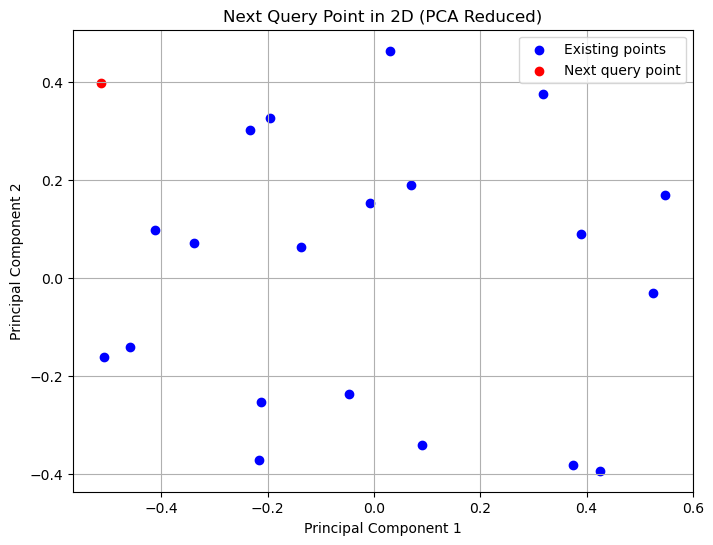

Next query point in 4D: [0.81212159 0.00981217 0.68102396 0.23803587]


In [168]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 5 (chemical process optimization)
X_train = np.array([[0.19144708, 0.03819337, 0.60741781, 0.41458414],
                    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
                    [0.43834987, 0.8043397 , 0.21024527, 0.15129482],
                    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
                    [0.83647799, 0.19360965, 0.6638927 , 0.78564888],
                    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
                    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
                    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
                    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
                    [0.46344227, 0.63002451, 0.10790646, 0.9576439 ],
                    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
                    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
                    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
                    [0.51114177, 0.817957  , 0.72871042, 0.11235362],
                    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
                    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
                    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
                    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
                    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
                    [0.12688467, 0.15342962, 0.77016219, 0.19051811]])

y_train = np.array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00, 
                    2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
                    8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
                    6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
                    2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    """
    Expected Improvement (EI) acquisition function with exploration.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter (larger xi = more exploration)
    """
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 4))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1)])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 4D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 4D
print("Next query point in 4D:", next_query_point)

## Function 6

Function 6 is a 5D optimization problem where the goal is to optimize a cake recipe. The recipe consists of five ingredients, and the objective is to maximize a combined score based on various factors like flavor, consistency, calories, waste, and cost. The output score is negative by design, so the task is to maximize the negative of the total sum, essentially bringing the score closer to zero.

Since this is a maximization problem, the goal is to find the combination of ingredients that results in the highest possible score. Because this is Week 1, exploration is prioritised over exploitation to efficiently explore the parameter space and avoid getting stuck in local optima early in the optimisation process.

#### Key Approach:

1. Gaussian Process (GP): The GP model will be used as the surrogate model for Function 6. This model will approximate the underlying function and help guide the optimization process.

2. Acquisition Function: The Expected Improvement (EI) acquisition function will be used to select the next query point. By setting a higher xi (exploration parameter), the algorithm will prioritise exploring areas with high uncertainty.

3. Optimisation: The goal is to iteratively find the next query point and use the GP model to guide the search towards better solutions.

#### Code Implementation for Function 6:

The code provided will:

1. Train a GP model on the provided data.

2. Use Expected Improvement (EI) to find the next query point.

3. Plot the next query point (after reducing dimensionality using PCA).


#### Explanation of the Code:

1. Model Setup: GaussianProcessRegressor with a RBF kernel (Radial Basis Function kernel) to model the unknown 5D function. The GP will approximate the function based on the data, and the kernel helps to model the smoothness of the function.

2. Acquisition Function (EI): The Expected Improvement (EI) function is used to choose the next query point by balancing exploration and exploitation, but in this case, the parameter xi is used to increase exploration (higher xi favors exploring uncertain regions).

3. Optimisation: Use scipy.optimize.minimize to optimise the EI acquisition function and find the next query point. This minimises the acquisition function, but negation applies since EI is a maximisation function.

4. PCA Visualisation: Since we have 5D data, it's difficult to directly visualise the query points in the original space. Use Principal Component Analysis (PCA) to reduce the dimensionality of the data to 2D for visualisation purposes. The plot shows the existing query points and the next query point (red dot) projected into 2D.

### Explanation of Function 6 

#### 1. Context of Function 6:

Function: Optimizes a cake recipe with 5 ingredient inputs (e.g., flour, sugar, eggs, butter, milk).

Output: A negative score combining flavor, consistency, calories, waste, and cost (negative by design).

Goal: Maximize this function — i.e., find input parameters that bring the score closest to zero (best combined quality).

Challenge: The function is unknown, expensive to evaluate, and treated as a black box.

#### 2. What the plot shows:

The plot is a 2D visualization of points in the original 5D input space, reduced by Principal Component Analysis (PCA).

Blue points represent the existing evaluated input recipes.

The red point is the next suggested query point chosen by the Bayesian optimization method (Gaussian Process + Expected Improvement acquisition function).

The PCA allows visualizing the relative positions of points in a compressed 2D space so you can see how the next query point relates spatially to previous data.

#### 3. Next Query Point in 5D:

The printed 5D input for the next recipe to try is:

[0.86482159, 0.77216426, 0.80394071, 0.78055099, 0.90903623]


This means the optimization algorithm suggests testing a cake recipe with ingredient proportions or parameters close to these values, normalized between 0 and 1.

#### 4. Why this next query point?

The acquisition function (Expected Improvement with exploration) chose this point to balance exploration and exploitation.

Since this is Week 1 (early phase), the model prioritizes exploration, so it looks for areas with:

High uncertainty in the prediction (where the model is less confident),

Potentially better results than previous observations.

The selected point might be in a less explored region near the cluster of existing points but not too close, aiming to gain new knowledge about the function landscape.

#### 5. Interpretation of the PCA plot location:

The red point is near the cluster of existing blue points but not exactly overlapping.

This suggests the algorithm wants to test a new recipe variant close to but distinct from previously tried recipes.

It balances trying promising areas with sampling unexplored or uncertain regions to improve the model’s understanding.

#### 6. Summary:

The next query point represents the recipe input to try next in the real world or experiment.

It’s chosen to improve knowledge about the function while still having a chance to find better scores.

The 2D PCA plot visually confirms the new query point’s relative novelty and strategic placement.

In [169]:
# Function 6 input values 5D array (20, 5)
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_6/initial_inputs.npy')

array([[0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
       [0.24238435, 0.84409997, 0.5778091 , 0.67902128, 0.50195289],
       [0.72952261, 0.7481062 , 0.67977464, 0.35655228, 0.67105368],
       [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
       [0.6188123 , 0.33180214, 0.18728787, 0.75623847, 0.3288348 ],
       [0.78495809, 0.91068235, 0.7081201 , 0.95922543, 0.0049115 ],
       [0.14511079, 0.8966846 , 0.89632223, 0.72627154, 0.23627199],
       [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
       [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
       [0.75759436, 0.35583141, 0.0165229 , 0.4342072 , 0.11243304],
       [0.5367969 , 0.30878091, 0.41187929, 0.38822518, 0.5225283 ],
       [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
       [0.6293079 , 0.80348368, 0.81140844, 0.04561319, 0.11062446],
       [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
       [0.43934426, 0.69892383, 0.

In [170]:
# Function 6 output values 1D array (20, )
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_6/initial_outputs.npy')

array([-0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
       -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
       -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254 ,
       -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209])

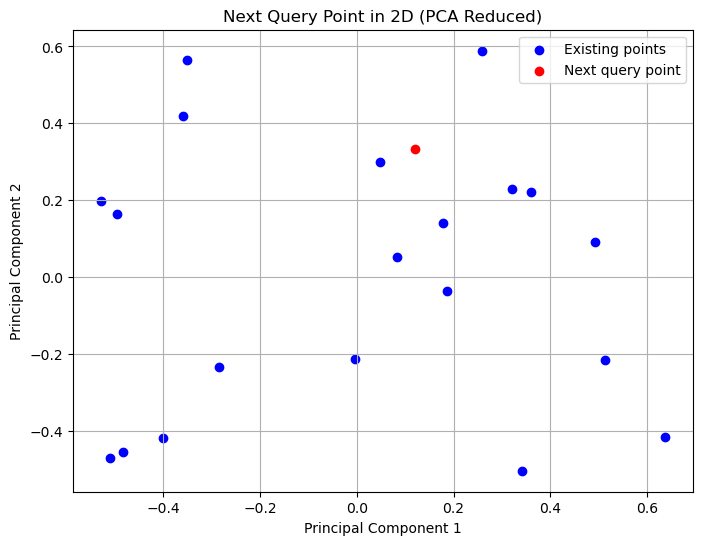

Next query point in 5D: [0.86482159 0.77216426 0.80394071 0.78055099 0.90903623]


In [171]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 6 (cake recipe optimization)
X_train = np.array([[0.7281861 , 0.15469257, 0.73255167, 0.69399651, 0.05640131],
                    [0.24238435, 0.84409997, 0.5778091 , 0.67902128, 0.50195289],
                    [0.72952261, 0.7481062 , 0.67977464, 0.35655228, 0.67105368],
                    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
                    [0.6188123 , 0.33180214, 0.18728787, 0.75623847, 0.3288348 ],
                    [0.78495809, 0.91068235, 0.7081201 , 0.95922543, 0.0049115 ],
                    [0.14511079, 0.8966846 , 0.89632223, 0.72627154, 0.23627199],
                    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
                    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
                    [0.75759436, 0.35583141, 0.0165229 , 0.4342072 , 0.11243304],
                    [0.5367969 , 0.30878091, 0.41187929, 0.38822518, 0.5225283 ],
                    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
                    [0.6293079 , 0.80348368, 0.81140844, 0.04561319, 0.11062446],
                    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
                    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
                    [0.25890557, 0.79367771, 0.6421139 , 0.19667346, 0.59310318],
                    [0.43216593, 0.71561781, 0.3418191 , 0.70499988, 0.61496184],
                    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
                    [0.9217762 , 0.93187122, 0.41487637, 0.59505727, 0.73562569],
                    [0.12667892, 0.2914703 , 0.06452848, 0.6805146 , 0.89281919]])

y_train = np.array([-0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
                    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
                    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254 ,
                    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    """
    Expected Improvement (EI) acquisition function with exploration.
    x: The point at which to evaluate the acquisition function
    model: The trained GaussianProcessRegressor model
    X_train: The previously evaluated points
    y_train: The previously observed values
    xi: Exploration-exploitation trade-off parameter (larger xi = more exploration)
    """
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 5))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 5D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 5D
print("Next query point in 5D:", next_query_point)

## Function 7

Function 7 represents a 6-dimensional optimisation problem where the task is to find the optimal combination of six hyperparameters to maximise the performance of a machine learning model. This function is black-box, meaning the relationship between the hyperparameters and the output (performance score) is unknown. The goal is to tune these hyperparameters (e.g., learning rate, regularization strength, number of hidden layers, etc.) to maximize the model's performance score (such as accuracy, F1-score, etc.).

#### Objective

Maximize the performance score of the model based on the values of six hyperparameters.

This is a maximization problem, but since the function is black-box, it's treated as an unknown function.

Exploration is prioritised in Week 1, meaning the goal is to explore a wide range of hyperparameters to gather sufficient data and avoid getting stuck in local optima early in the optimisation process.

#### Bayesian Optimization Approach:

Gaussian Process (GP): A surrogate model that approximates the black-box function.

Expected Improvement (EI): The acquisition function used to guide the optimization towards the next best query point, balancing exploration and exploitation.

Acquisition Function: EI is used to find the next point that will likely improve the performance of the model.

#### Key Code Concepts:

GaussianProcessRegressor: A regression model used to approximate the objective function based on data points.

Expected Improvement (EI): An acquisition function that helps select the next query point. It prioritizes uncertainty (exploration) early in the optimization.

PCA (Principal Component Analysis): Used to reduce the dimensionality of the data from 6D to 2D, making it possible to visualize the input space.

Optimization: The acquisition function is optimized to select the next query point in the 6D space.

#### Explanation:

Gaussian Process (GP): A Gaussian Process model is used to approximate the relationship between the 6 hyperparameters and the performance score (output). The RBF kernel helps model the smoothness of the function.

Expected Improvement (EI): The acquisition function (Expected Improvement) is used to choose the next point based on exploration and exploitation. The parameter xi ensures that the algorithm prioritizes exploration early in the optimization process.

Optimization: The next query point is selected by optimizing the EI acquisition function using scipy.optimize.minimize.

Dimensionality Reduction (PCA): Since the input space is 6D, PCA (Principal Component Analysis) is used to reduce the dimensionality of the data to 2D for visualization purposes.

Plotting: The blue dots represent the existing query points, and the red dot represents the next query point suggested by the optimizer. The next query point is projected onto a 2D space using PCA for easier visualization.

In [172]:
# Function 7 input values 6D array (30, 6)
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_7/initial_inputs.npy')

array([[0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269,
        0.79586362],
       [0.54300258, 0.9246939 , 0.34156746, 0.64648585, 0.71844033,
        0.34313266],
       [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285,
        0.6402654 ],
       [0.11886697, 0.61505494, 0.90581639, 0.8553003 , 0.41363143,
        0.58523563],
       [0.63021764, 0.8380969 , 0.68001305, 0.73189509, 0.52673671,
        0.34842921],
       [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277,
        0.09579366],
       [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833,
        0.73096984],
       [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418,
        0.10703171],
       [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083,
        0.6924164 ],
       [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917,
        0.05109986],
       [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098,
        0.63747637],
       [0.72261522, 0

In [175]:
# Function 7 output values 1D array (30, )
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_7/initial_outputs.npy')

array([0.6044327 , 0.56275307, 0.00750324, 0.0614243 , 0.2730468 ,
       0.08374657, 1.3649683 , 0.09264495, 0.0178696 , 0.03356494,
       0.0735163 , 0.2063097 , 0.00882563, 0.26840032, 0.61152553,
       0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
       0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
       0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116])

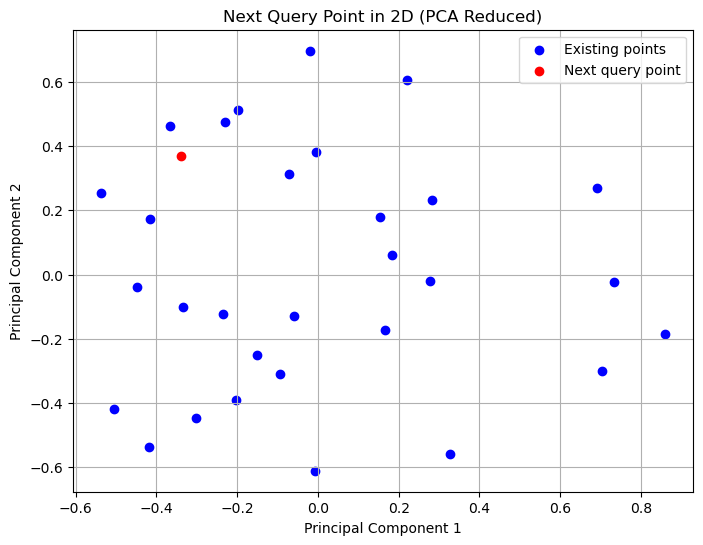

Next query point in 6D: [0.43268546 0.65667787 0.11740649 0.35572188 0.83246224 0.0725535 ]


In [176]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 7 (ML hyperparameter optimization)
X_train = np.array([[0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
                    [0.54300258, 0.9246939 , 0.34156746, 0.64648585, 0.71844033, 0.34313266],
                    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.6402654 ],
                    [0.11886697, 0.61505494, 0.90581639, 0.8553003 , 0.41363143, 0.58523563],
                    [0.63021764, 0.8380969 , 0.68001305, 0.73189509, 0.52673671, 0.34842921],
                    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
                    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
                    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
                    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.6924164 ],
                    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
                    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
                    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
                    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
                    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
                    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
                    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
                    [0.41762629, 0.06409998, 0.24566877, 0.5590408 , 0.19153138, 0.25464092],
                    [0.72628566, 0.46489581, 0.92457051, 0.8072454 , 0.6354384 , 0.14341787],
                    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.6190825 ],
                    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
                    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
                    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
                    [0.68685257, 0.04101721, 0.00757301, 0.285009  , 0.69156848, 0.6555429 ],
                    [0.17597754, 0.6244165 , 0.29554198, 0.46955276, 0.09776977, 0.72814108],
                    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
                    [0.06661051, 0.52804507, 0.8160952 , 0.96101714, 0.08650933, 0.77778822],
                    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
                    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.5523983 , 0.08130609],
                    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.7193764 , 0.36288398],
                    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.9986547 , 0.07966402]])

y_train = np.array([0.6044327 , 0.56275307, 0.00750324, 0.0614243 , 0.2730468 ,
                    0.08374657, 1.3649683 , 0.09264495, 0.0178696 , 0.03356494,
                    0.0735163 , 0.2063097 , 0.00882563, 0.26840032, 0.61152553,
                    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
                    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
                    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.1):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 6))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)])
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 6D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 6D
print("Next query point in 6D:", next_query_point)

## Function 8

Function 8 is an 8-dimensional optimization problem where the goal is to maximize the output of a complex, black-box function. This function could represent an ML model performance (e.g., validation accuracy) depending on eight hyperparameters (e.g., learning rate, batch size, number of layers, dropout rate, etc.). The function is high-dimensional and its internal mechanics are unknown.

Given this complexity and the high-dimensional input space, the goal for Week 1 is to prioritize exploration over exploitation. This means exploring a wide range of hyperparameters to gather more information about the function and avoid getting stuck in local optima early in the optimization process.

Approach:

We will use Bayesian Optimization with the following components:

1. Gaussian Process (GP): This model will approximate the unknown function.

2. Expected Improvement (EI): The acquisition function to select the next query point, which balances exploration and exploitation.

3. Optimization: The acquisition function will guide the search for the next best query point.

4. Dimensionality Reduction (PCA): Given the input space is 8D, we will use PCA (Principal Component Analysis) to reduce the dimensionality to 2D for visualization.

#### Key Steps and Explanation:

1. GP Model Setup: The GaussianProcessRegressor is initialized with an RBF kernel to model the relationship between the 8 hyperparameters and the performance score. The kernel models the smoothness of the function.

2. Expected Improvement (EI): This acquisition function helps guide the optimization process. It looks for points where the expected improvement is high, balancing exploration (uncertainty) and exploitation (current best-known point).

3. Acquisition Optimization: The acquisition function is optimized using scipy.optimize.minimize to find the next query point in the 8D space. The bounds of the optimization are set between 0 and 1 for each of the 8 input dimensions.

4. PCA for Visualization: Since the input space is 8D, PCA is used to reduce the dimensionality to 2D for easier visualization. This helps visualize where the next query point lies relative to the existing points.

5. Plot: The plot shows the existing query points in blue and the next query point in red, projected into a 2D space using PCA.

6. Output: The next query point is printed in 8D coordinates, representing the new hyperparameters to test.

In [177]:
# Function 8 input values 8D array (40, 8)
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_8/initial_inputs.npy')

array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.0937283 ,
        0.19742533, 0.7558269 , 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.0034195 , 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.5513471 , 0.66003209],
       [0.90864932, 0.0622497 , 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.631379

In [178]:
# Function 8 output values 1D array (40, )
np.load('Documents/Imperial College London 25 Week AI ML Course October 2025/ICL Professional Certificate in ML AI Modules/Module 12 BBO Capstone/initial_data/function_8/initial_outputs.npy')

array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
       8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
       7.85454099, 6.79198578, 8.97655402, 7.3790829 , 9.598482  ,
       8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
       7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
       8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
       7.92375877, 8.42175924, 8.2780624 , 7.11345716, 6.40258841,
       8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525])

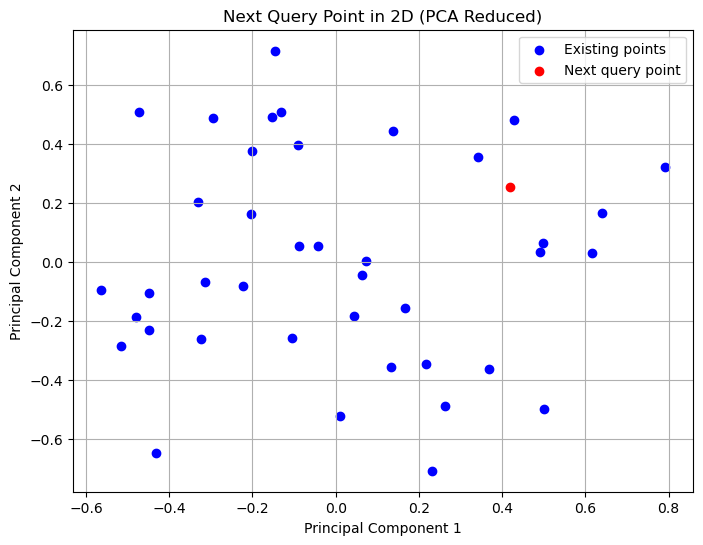

Next query point in 8D: [0.89543372 0.91202174 0.09815963 0.03666713 0.44513781 0.67979073
 0.2295436  0.76174224]


In [188]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.decomposition import PCA

# Step 1: Define the input and output data for function 8 (ML hyperparameter optimization)
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.0937283 ,
        0.19742533, 0.7558269 , 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.0034195 , 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.5513471 , 0.66003209],
       [0.90864932, 0.0622497 , 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.9849332 , 0.69950626, 0.9988855 , 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.1435503 , 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.2058408 ],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.2818694 , 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.3515119 , 0.59006494, 0.9094363 , 0.67840835, 0.21282566,
        0.08846038, 0.410153  , 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.3263292 ,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.9887551 ],
       [0.89888711, 0.5236417 , 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.3767511 , 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.6131746 , 0.67266045,
        0.02211341, 0.6014833 , 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.986902  ,
        0.53518298, 0.71474318, 0.96009372],
       [0.5327214 , 0.8336926 , 0.071399  , 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.127902  ],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.9067059 , 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.7407543 , 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.5609175 ],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.6388937 , 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.7066501 , 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164]])

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.3790829 , 9.598482  ,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.2780624 , 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525])

# Step 2: Define the Gaussian Process (GP) model
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))  # Constant kernel * RBF kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)

# Step 3: Fit the GP model to the existing data
gp.fit(X_train, y_train)

# Step 4: Define the Expected Improvement (EI) acquisition function with exploration
def expected_improvement(x, model, X_train, y_train, xi=0.2):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    y_best = np.max(y_train)  # Maximization problem
    improvement = mu - y_best - xi  # Subtract xi for exploration
    ei = improvement * norm.cdf(improvement / sigma) + sigma * norm.pdf(improvement / sigma)
    return -ei  # Minimize the acquisition function

# Step 5: Optimize the acquisition function to find the next query point
def optimize_acquisition(model, X_train, y_train, length=0.5, xi=0.1):
    # Random starting point for optimization
    x0 = np.random.uniform(0, 1, size=(1, 8))
    
    # Optimize the acquisition function
    res = minimize(expected_improvement, x0, args=(model, X_train, y_train, xi),
                   bounds=[(0, 1)] * 8)  # 8D bounds
    
    # Get the new query point
    new_x = res.x
    return new_x

# Step 6: Find the next query point
next_query_point = optimize_acquisition(gp, X_train, y_train)

# Step 7: Visualize the next query point in 2D using PCA (since we have 8D data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Reduce dimensionality to 2D

# Step 8: Plot the existing points and the next query point
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))  # Transform the next query point to 2D
plt.scatter(next_query_point_pca[:, 0], next_query_point_pca[:, 1], color='red', label='Next query point')

plt.title('Next Query Point in 2D (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

# Print the next query point in 8D
print("Next query point in 8D:", next_query_point)